In [2]:
import requests
import pandas as pd
import textstat
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

c:\Users\anush\anaconda3main\envs\steering\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
v_steering = np.load("v_steering.npy")

v_torch = torch.tensor(v_steering, dtype=torch.float16).to("cuda")

print("Vector shape:", v_torch.shape)

Vector shape: torch.Size([2560])


In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True
)

model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 453/453 [00:03<00:00, 137.61it/s, Materializing param=model.layers.31.self_attn.v_proj.weight]
Some parameters are on the meta device because they were offloaded to the cpu.


PhiForCausalLM(
  (model): PhiModel(
    (embed_tokens): Embedding(51200, 2560)
    (layers): ModuleList(
      (0-31): 32 x PhiDecoderLayer(
        (self_attn): PhiAttention(
          (q_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (k_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (v_proj): Linear(in_features=2560, out_features=2560, bias=True)
          (dense): Linear(in_features=2560, out_features=2560, bias=True)
        )
        (mlp): PhiMLP(
          (activation_fn): NewGELUActivation()
          (fc1): Linear(in_features=2560, out_features=10240, bias=True)
          (fc2): Linear(in_features=10240, out_features=2560, bias=True)
        )
        (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (rotary_emb): PhiRotaryEmbedding()
    (embed_dropout): Dropout(p=0.0, inplace=False)
    (final_layernorm): LayerNorm((2560,), eps=1

In [6]:
def measure_hidden_norm():
    inputs = tokenizer("Test sentence.", return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)
    h = outputs.hidden_states[16]
    return torch.norm(h, dim=-1).mean().item()

hidden_norm = measure_hidden_norm()
print("Hidden norm:", hidden_norm)

scale_fraction = 0.1  # 10% (you can tune 0.05–0.2)
v_scaled = v_torch * (hidden_norm * scale_fraction)

print("Scaled vector norm:", torch.norm(v_scaled).item())

Hidden norm: 482.0
Scaled vector norm: 48.1875


In [7]:
scale_fraction = 0.05  # safer, stable

v_scaled = v_torch * (hidden_norm * scale_fraction)

print("Scaled vector norm:", torch.norm(v_scaled).item())

Scaled vector norm: 24.09375


In [ ]:
def make_hook(alpha):
    def hook(module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
            rest = output[1:]

            steered = hidden_states - alpha * v_scaled
            return (steered, *rest)
        else:
            return output - alpha * v_scaled

    return hook

In [9]:
def generate_with_steering(prompt, alpha=0.0, max_new_tokens=120):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    hook = model.model.layers[16].register_forward_hook(make_hook(alpha))

    try:
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                min_new_tokens=30,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=tokenizer.eos_token_id
            )
    finally:
        hook.remove()

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [10]:
def clean_output(text):
    stop_tokens = ["Exercise", "Question", "Solution:", "\n\n\n"]
    
    for tok in stop_tokens:
        if tok in text:
            text = text.split(tok)[0]
    
    return text.strip()

def readability(text):
    return (
        flesch_reading_ease(text),
        flesch_kincaid_grade(text)
    )

In [11]:
def make_prompt(q):
    return f"Explain: {q}\nThe explanation is:"

In [13]:
def readability(text):
    return (
        textstat.flesch_reading_ease(text),
        textstat.flesch_kincaid_grade(text)
    )

In [15]:
alphas = [-2.0, -1.0, -0.5, 0, 0.5, 1.0, 2.0]

q = "How do vaccines work?"

for a in alphas:
    text = generate_with_steering(make_prompt(q), alpha=a)
    text = clean_output(text)

    fre, fk = readability(text)

    print(f"\nAlpha {a}")
    print(text[:200])
    print(f"FRE: {fre:.2f}, FKGL: {fk:.2f}")


Alpha -2.0
Explain: How do vaccines work?
The explanation is: Vaccines help our body's immune system get ready to fight germs that make us sick. They have a special code inside them, and when we get the vaccine,
FRE: 76.55, FKGL: 6.72

Alpha -1.0
Explain: How do vaccines work?
The explanation is: Vaccines are like special medicine that help our body's immune system learn how to fight off germs. They have a little piece of the germ inside them,
FRE: 79.78, FKGL: 5.81

Alpha -0.5
Explain: How do vaccines work?
The explanation is: Vaccines work by introducing a weakened or inactive form of the virus into our body. This helps our immune system recognize and remember the virus, s
FRE: 54.56, FKGL: 9.79

Alpha 0
Explain: How do vaccines work?
The explanation is: Vaccines are substances that contain weakened or killed forms of the disease-causing microorganisms, such as viruses or bacteria. When a person recei
FRE: 23.28, FKGL: 14.04

Alpha 0.5
Explain: How do vaccines work?
The explanation 

In [ ]:
questions = [
    "What is gravity?",
    "How does photosynthesis work?",
    "What is a neural network?"
]

alphas = [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
results = []

for q in questions:
    print(f"\n\n===== QUESTION: {q} =====")
    
    for a in alphas:
        text = generate_with_steering(make_prompt(q), alpha=a)
        text = clean_output(text)

        fre, fk = readability(text)

        print(f"Alpha {a:>4} | FRE: {fre:>6.2f} | FKGL: {fk:>5.2f}")

        results.append({
            "question": q,
            "text":text,
            "alpha": a,
            "fre": fre,
            "fkgl": fk
        })

df_alpha = pd.DataFrame(results)



===== QUESTION: What is gravity? =====
Alpha -2.0 | FRE:  78.90 | FKGL:  5.26
Alpha -1.0 | FRE:  88.73 | FKGL:  3.81
Alpha -0.5 | FRE:  59.81 | FKGL:  9.74
Alpha  0.0 | FRE:  60.23 | FKGL:  8.09
Alpha  0.5 | FRE:  59.15 | FKGL:  8.24
Alpha  1.0 | FRE:  45.18 | FKGL: 10.44
Alpha  2.0 | FRE:  22.66 | FKGL: 13.76


===== QUESTION: How does photosynthesis work? =====
Alpha -2.0 | FRE:  71.94 | FKGL:  6.08
Alpha -1.0 | FRE:  50.27 | FKGL:  9.31
Alpha -0.5 | FRE:  49.87 | FKGL:  9.16
Alpha  0.0 | FRE:  56.58 | FKGL:  8.39
Alpha  0.5 | FRE:  34.13 | FKGL: 12.16
Alpha  1.0 | FRE:  42.73 | FKGL: 10.65
Alpha  2.0 | FRE:  29.26 | FKGL: 12.69


===== QUESTION: What is a neural network? =====
Alpha -2.0 | FRE:  76.54 | FKGL:  6.35


In [3]:
import pandas as pd

df = pd.read_csv("alpha_sweep.csv")

df_mean = df.groupby("alpha")[["fre", "fkgl"]].mean().reset_index()

In [4]:
print(df_mean)

   alpha        fre       fkgl
0   -2.0  77.323333   5.723333
1   -1.0  73.506667   6.090000
2   -0.5  63.686667   8.013333
3    0.0  57.053333   8.980000
4    0.5  38.940000  11.386667
5    1.0  39.923333  11.230000
6    2.0  25.200000  13.273333


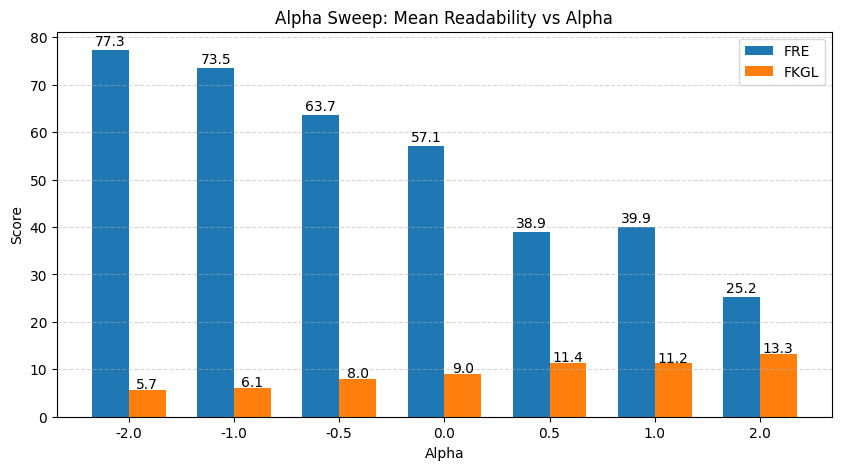

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df_mean["alpha"]))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, df_mean["fre"], width, label="FRE")
bars2 = plt.bar(x + width/2, df_mean["fkgl"], width, label="FKGL")

plt.xticks(x, df_mean["alpha"])
plt.xlabel("Alpha")
plt.ylabel("Score")
plt.title("Alpha Sweep: Mean Readability vs Alpha")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 🔥 add labels on top
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}", ha='center')

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha='center')

plt.show()

In [6]:
#chosen alpha levels
LEVELS = {
    "beginner": -2.0,
    "intermediate": 0.0,
    "expert": 2.0
}